# 03_Visualization
<div style="height:10px;background:#F9A825;border-radius:5px;margin:25px 0;"></div>


In [36]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter


def format_count(x, _):
    """Formatter fuer Achsen-Ticks, z.B. 20000 -> '20,000'."""
    return f"{int(x):,}"


In [37]:
conn = sqlite3.connect("../data/cleaned/names_clean.sqlite")


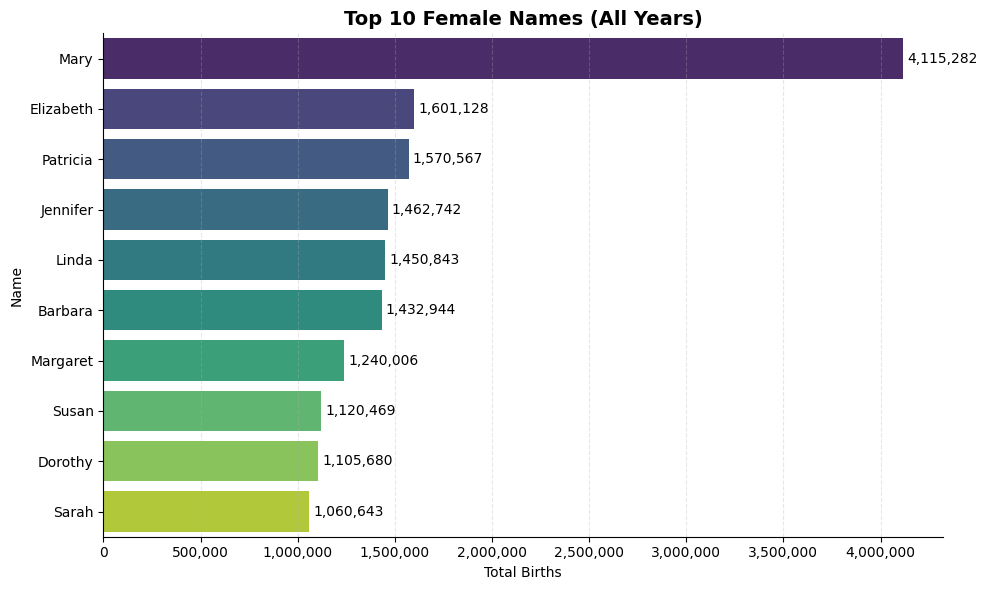

In [38]:
query = """
SELECT Name, SUM(Count) AS Total
FROM NationalNames
WHERE Gender = 'F'
GROUP BY Name
ORDER BY Total DESC
LIMIT 10;
"""

top10_female = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top10_female,
    x="Total",
    y="Name",
    hue="Name",
    palette="viridis",
    legend=False
)

plt.gca().xaxis.set_major_formatter(FuncFormatter(format_count))

for i, value in enumerate(top10_female["Total"]):
    ax.text(value + 20000, i, f"{value:,}", va="center", fontsize=10)

plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()

plt.title("Top 10 Female Names (All Years)", fontsize=14, weight="bold")
plt.xlabel("Total Births")
plt.ylabel("Name")

plt.tight_layout()
plt.show()


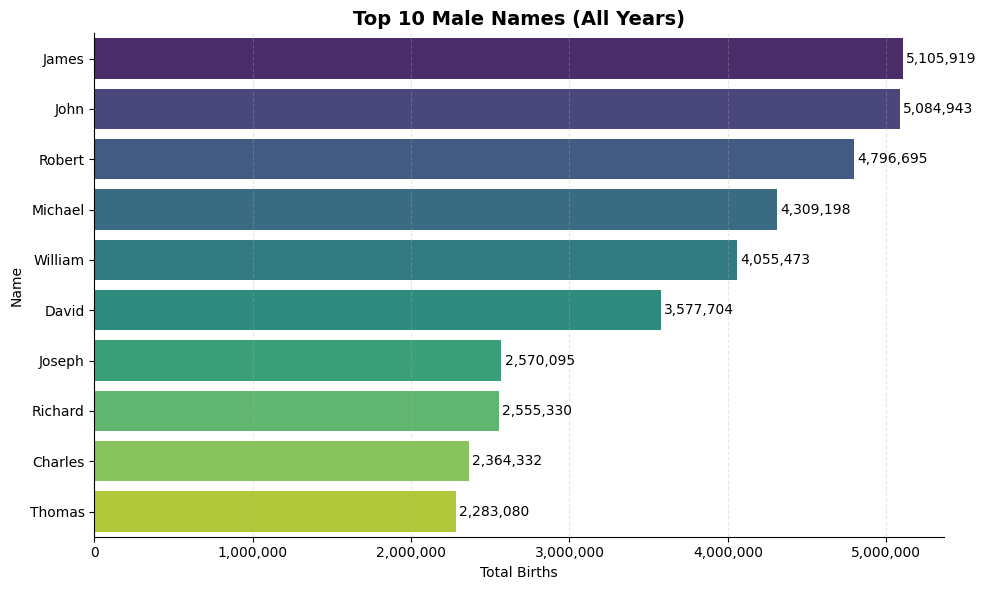

In [39]:
query = """
SELECT Name, SUM(Count) AS Total
FROM NationalNames
WHERE Gender = 'M'
GROUP BY Name
ORDER BY Total DESC
LIMIT 10;
"""

top10_male = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top10_male,
    x="Total",
    y="Name",
    hue="Name",
    palette="viridis",
    legend=False
)

plt.gca().xaxis.set_major_formatter(FuncFormatter(format_count))

for i, value in enumerate(top10_male["Total"]):
    ax.text(value + 20000, i, f"{value:,}", va="center", fontsize=10)

plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()

plt.title("Top 10 Male Names (All Years)", fontsize=14, weight="bold")
plt.xlabel("Total Births")
plt.ylabel("Name")

plt.tight_layout()
plt.show()


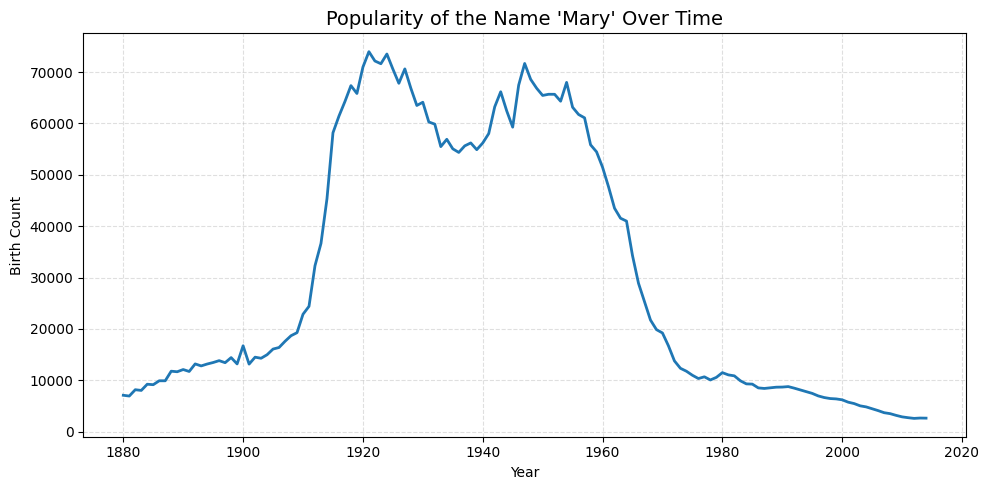

In [40]:
query = """
SELECT Year, SUM(Count) AS TotalCount
FROM NationalNames
WHERE Name = 'Mary'
  AND Gender = 'F'
GROUP BY Year
ORDER BY Year;
"""

mary = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 5))

sns.lineplot(data=mary, x="Year", y="TotalCount", linewidth=2)

plt.title("Popularity of the Name 'Mary' Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Birth Count")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()


<div style="border-left:5px solid #F9A825; padding-left:15px;">

### Finding

Although **Mary** is the most common female name across the entire dataset, its popularity has declined significantly in recent decades.

The high cumulative total is primarily the result of its sustained popularity throughout the late 19th and much of the 20th century.

</div>


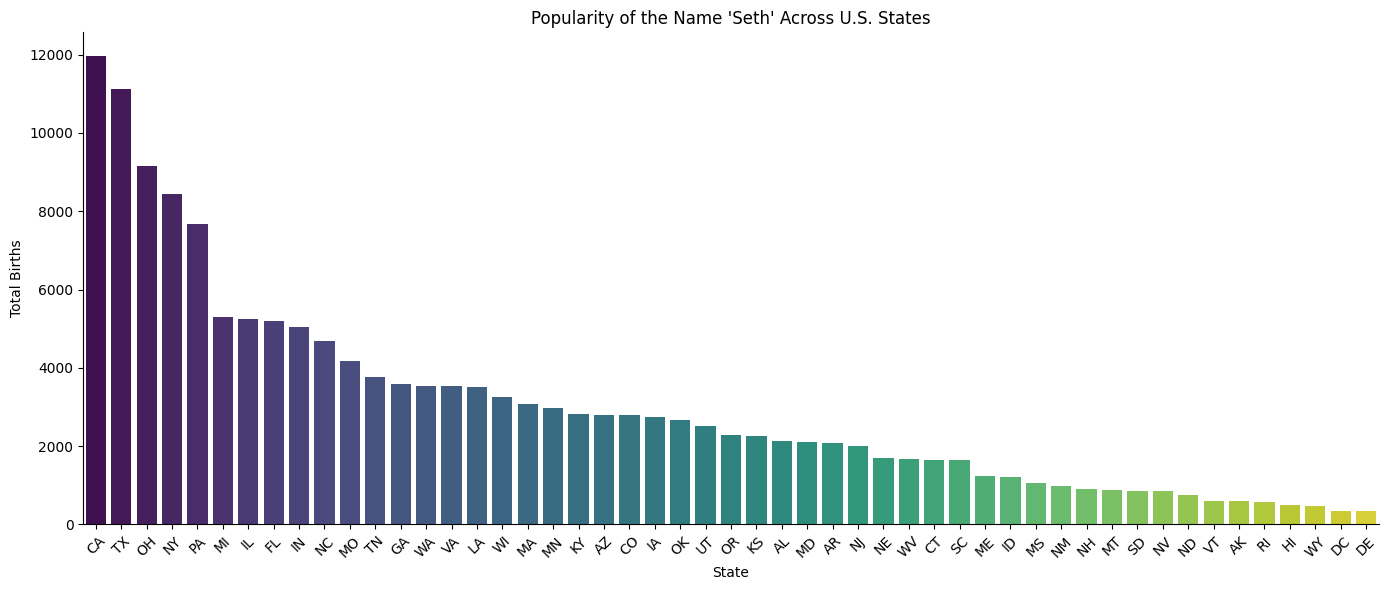

In [41]:
query = """
SELECT State, SUM(Count) AS TotalCount
FROM StateNames
WHERE Name = 'Seth'
GROUP BY State
ORDER BY TotalCount DESC;
"""

seth = pd.read_sql_query(query, conn)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=seth,
    x="State",
    y="TotalCount",
    hue="State",
    palette="viridis",
    legend=False
)

plt.title("Popularity of the Name 'Seth' Across U.S. States")
plt.xlabel("State")
plt.ylabel("Total Births")
plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()
plt.show()


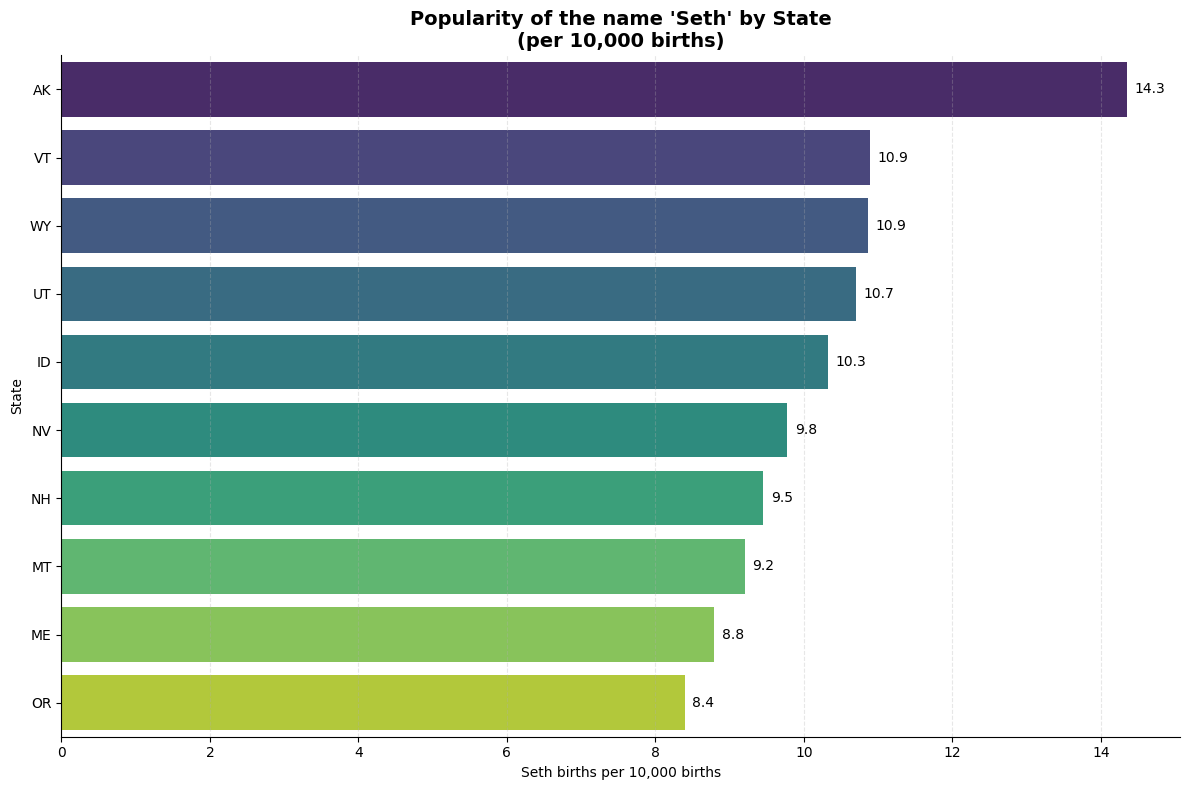

In [42]:
query = """
SELECT
    s.State,
    SUM(s.Count) AS SethBirths,
    t.TotalBirths,
    10000.0 * SUM(s.Count) / t.TotalBirths AS SethPer10000
FROM StateNames s
JOIN (
    SELECT State, SUM(Count) AS TotalBirths
    FROM StateNames
    GROUP BY State
) t
ON s.State = t.State
WHERE s.Name = 'Seth'
GROUP BY s.State
ORDER BY SethPer10000 DESC
LIMIT 10;
"""

seth_relative = pd.read_sql_query(query, conn)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=seth_relative,
    x="SethPer10000",
    y="State",
    hue="State",
    palette="viridis",
    legend=False
)

for i, value in enumerate(seth_relative["SethPer10000"]):
    ax.text(value + 0.1, i, f"{value:.1f}", va="center", fontsize=10)

plt.title("Popularity of the name 'Seth' by State\n(per 10,000 births)", fontsize=14, weight="bold")
plt.xlabel("Seth births per 10,000 births")
plt.ylabel("State")

plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()


In [43]:
query = """
SELECT Year, SUM(Count) AS TotalCount
FROM NationalNames
WHERE Name = 'Melanie'
  AND Gender = 'F'
GROUP BY Year
ORDER BY TotalCount DESC
LIMIT 10;
"""

mel = pd.read_sql_query(query, conn)
print(mel)


   Year  TotalCount
0  1972        6294
1  1973        6079
2  1974        5483
3  1977        5369
4  1975        5367
5  1976        5240
6  1971        5140
7  1979        5023
8  1978        4995
9  1980        4844


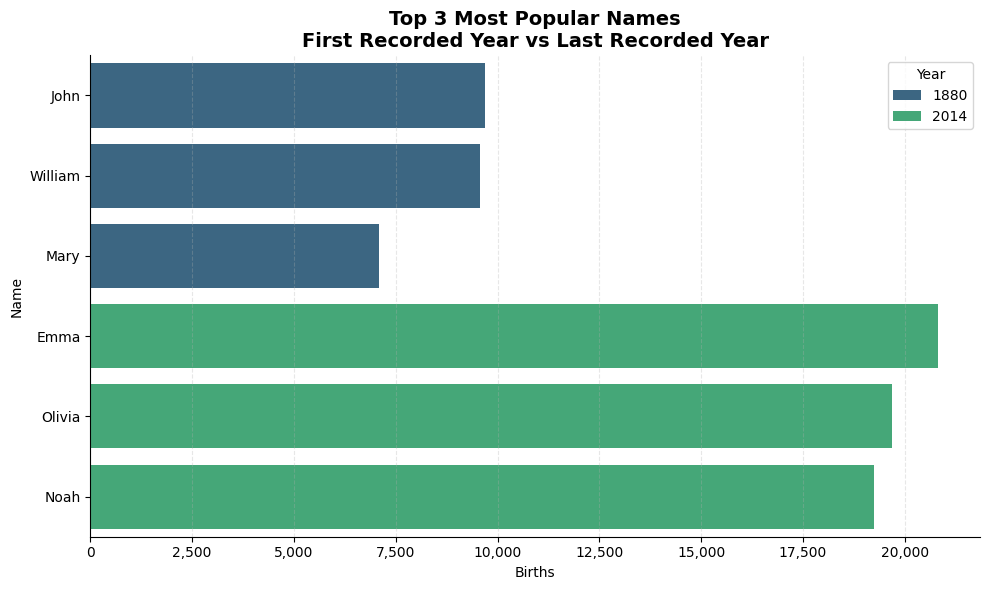

In [44]:
query = """
SELECT *
FROM (
    SELECT CAST((SELECT MIN(Year) FROM NationalNames) AS TEXT) AS Year, Name, SUM(Count) AS Births
    FROM NationalNames
    WHERE Year = (SELECT MIN(Year) FROM NationalNames)
    GROUP BY Name
    ORDER BY Births DESC
    LIMIT 3
)
UNION ALL
SELECT *
FROM (
    SELECT CAST((SELECT MAX(Year) FROM NationalNames) AS TEXT) AS Year, Name, SUM(Count) AS Births
    FROM NationalNames
    WHERE Year = (SELECT MAX(Year) FROM NationalNames)
    GROUP BY Name
    ORDER BY Births DESC
    LIMIT 3
);
"""

top_names = pd.read_sql_query(query, conn)

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=top_names, x="Births", y="Name", hue="Year", palette="viridis")

plt.gca().xaxis.set_major_formatter(FuncFormatter(format_count))

plt.title("Top 3 Most Popular Names\nFirst Recorded Year vs Last Recorded Year", fontsize=14, weight="bold")
plt.xlabel("Births")
plt.ylabel("Name")

plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()


In [45]:
conn.close()
